In [4]:
from gunicorn.util import positionals
from matplotlib.pyplot import xlabel
from mlflow.protos.databricks_pb2 import visibility

import lis2.skeletons.utils as utils
import os
import numpy as np
from astropy.io import fits
from astropy.wcs import WCS
import matplotlib.pyplot as plt



/home/benielli/Space/Projets/LIS2/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


# ____________________________________________________________________

==========
# FIGURES
==========

## 1 Classical MAP 2D (from representation opacity)

### 1.1 Data

In [2]:
path_3Ddata = "../../../BIGSF_DATA/Clustering_COHRS/COHRS_10p50_0p00_CUBE_3T2_R2.fit"
#path_3Ddata_reprojected = "../../../BIGSF_DATA/Clustering_COHRS/COHRS_reprojected_Unet_fromCut.fits"
#path_spines = "../../../BIGSF_DATA/Clustering_COHRS/Cut.fits"
path_3Ddata_reprojected = "../../../BIGSF_DATA/Clustering_COHRS/COHRS_reprojected_10p50_0p00_CUBE_3T2_R2.fits"
path_spines = "../../../BIGSF_DATA/Clustering_COHRS/new_full_mask_002011.fits"
data_3D = fits.open(path_3Ddata)
data_spine = fits.open(path_spines)
data_reproject = fits.open(path_3Ddata_reprojected)

In [5]:
wcs_3d_1 = WCS(data_reproject[0].header.copy())
wcs_3d_1_r = wcs_3d_1.celestial
# WCS du spine et du cube
wcs_spine = WCS(data_spine[0].header).celestial
wcs_cube = WCS(data_reproject[0].header).celestial


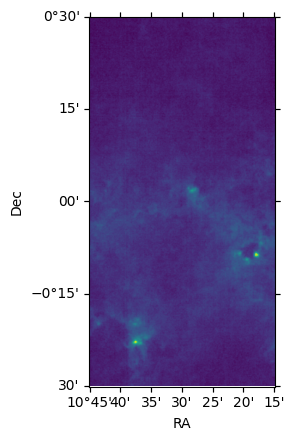

In [6]:
wcs_3d = WCS(data_3D[0].header.copy())
wcs_3d_c = wcs_3d.celestial
fig = plt.figure()
fig.add_subplot(111, projection=wcs_3d_c)
plt.imshow(data_3D[0].data.sum(axis=0), origin='lower', cmap=plt.cm.viridis)
plt.xlabel('RA')
plt.ylabel('Dec')
corners_world = wcs_3d_c.calc_footprint()
min_ra, min_dec = corners_world.min(axis=0)
max_ra, max_dec = corners_world.max(axis=0)
data_s2_wcs = WCS(data_spine[0].header)
# Find these corners inside 2D mask data
min_pix_x, min_pix_y = data_s2_wcs.world_to_pixel_values(min_ra, min_dec)
max_pix_x, max_pix_y = data_s2_wcs.world_to_pixel_values(max_ra, max_dec)
min_pix_x, max_pix_x = int(min_pix_x), int(max_pix_x)
min_pix_y, max_pix_y = int(min_pix_y), int(max_pix_y)

(1111, 3871)


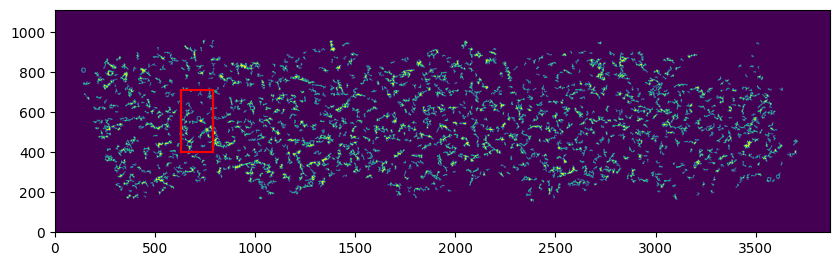

In [8]:
print(data_spine[0].data.shape)
wcs_2d = WCS(data_spine[0].header.copy())
plt.figure(figsize=(10, 10))
plt.imshow(data_spine[0].data, origin='lower')
corners_world = wcs_3d_1_r.calc_footprint()
min_ra, min_dec = corners_world.min(axis=0)
max_ra, max_dec = corners_world.max(axis=0)

# Find these corners inside 2D mask data
min_pix_x, min_pix_y = data_s2_wcs.world_to_pixel_values(min_ra, min_dec)
max_pix_x, max_pix_y = data_s2_wcs.world_to_pixel_values(max_ra, max_dec)
min_pix_x, max_pix_x = int(min_pix_x), int(max_pix_x)
min_pix_y, max_pix_y = int(min_pix_y), int(max_pix_y)
plt.plot([min_pix_x, max_pix_x ], [min_pix_y, min_pix_y], 'r')
plt.plot([min_pix_x, min_pix_x], [min_pix_y, max_pix_y], 'r')
plt.plot([max_pix_x, max_pix_x ], [max_pix_y, min_pix_y], 'r')
plt.plot([max_pix_x, min_pix_x], [max_pix_y, max_pix_y], 'r')

In [9]:
header_reproject = data_reproject[0].header
cube_shape = data_reproject[0].data.shape  # (velocity, y, x)
wcs_reproject = WCS(header_reproject).celestial
cube_corners_ra_dec = wcs_reproject.calc_footprint()

## 1.2 Skeleton cut

lon, lat [10.754649  10.2531148] [-0.50690434  0.49295355]
x_spine, y_spine [631. 788.] [399. 712.]
Découpe du spine : x=(631,788), y=(399,712)
cut shape (313, 157)
origin reproject shape (313, 157)
[min_pix_x, max_pix_x ], [min_pix_y, max_pix_y] [787, 630] [399, 710]


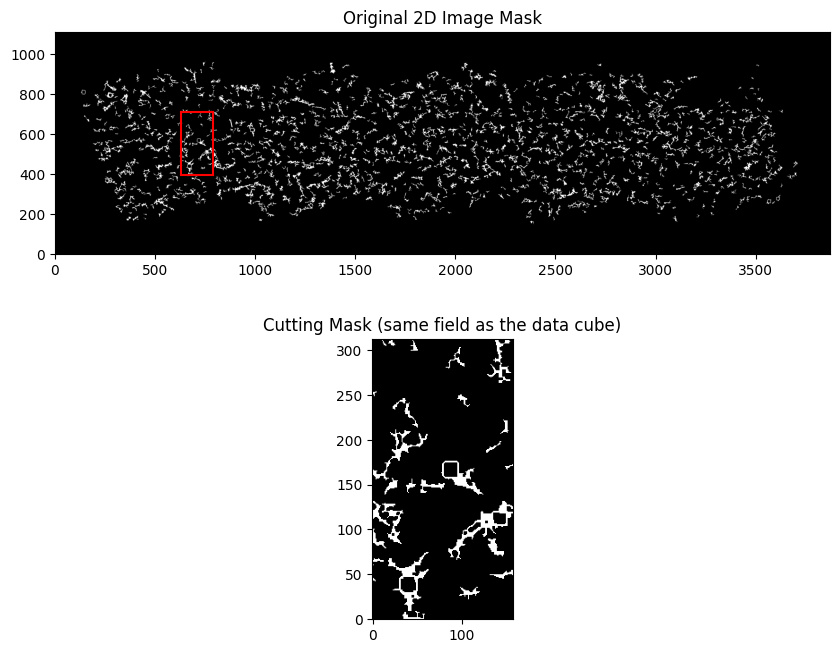

In [16]:
# Dimensions
ny_cube, nx_cube = data_reproject[0].data.shape[-2:]

# Coordonnées pixel du cube dans son propre WCS
x_cube = np.array([0, nx_cube])
y_cube = np.array([0, ny_cube])

# Convertir ces coins en coordonnées monde (GLON, GLAT)
lon, lat = wcs_cube.all_pix2world(x_cube, y_cube, 1)
print("lon, lat", lon, lat)
# Puis convertir ces coins dans le WCS du spine
x_spine, y_spine = wcs_spine.all_world2pix(lon, lat, 1)
print("x_spine, y_spine", x_spine, y_spine)
# Déterminer les bornes
x_min = int(np.floor(min(x_spine)))
x_max = int(np.ceil(max(x_spine)))
y_min = int(np.floor(min(y_spine)))
y_max = int(np.ceil(max(y_spine)))

print(f"Découpe du spine : x=({x_min},{x_max}), y=({y_min},{y_max})")

# Appliquer la découpe
data_spine_cut = data_spine[0].data[y_min:y_max, x_min:x_max]
print("cut shape", data_spine_cut.shape)
print("origin reproject shape", data_reproject[0].data.shape[-2:])
print ("[min_pix_x, max_pix_x ], [min_pix_y, max_pix_y]", [min_pix_x, max_pix_x ], [min_pix_y, max_pix_y] )
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 8))
plt.subplot(2,1,1)
plt.imshow(data_spine[0].data, origin='lower', cmap='gray')
plt.plot([min_pix_x, max_pix_x ], [min_pix_y, min_pix_y], 'r')
plt.plot([min_pix_x, min_pix_x], [min_pix_y, max_pix_y], 'r')
plt.plot([max_pix_x, max_pix_x ], [max_pix_y, min_pix_y], 'r')
plt.plot([max_pix_x, min_pix_x], [max_pix_y, max_pix_y], 'r')
plt.title("Original 2D Image Mask")
plt.subplot(2,1,2)
plt.imshow(data_spine_cut, origin='lower', cmap='gray')
plt.title("Cutting Mask (same field as the data cube)")
plt.show()

## 1.3 ske_label

In [12]:
from astropy.wcs import WCS
import numpy as np

# WCS du spine et du cube
wcs_spine = WCS(data_spine[0].header).celestial
wcs_cube = WCS(data_reproject[0].header).celestial

nz, ny, nx = cube_shape
wcs_cel = wcs_cube

wcs_reproject =  WCS(data_reproject[0].header)

# --- Axes physiques ---
# Longitude galactique (GLON)
l_vals = (np.arange(nx) - (wcs_reproject.wcs.crpix[0] - 1)) * wcs_reproject.wcs.cdelt[0] + wcs_reproject.wcs.crval[0]

# Latitude galactique (GLAT)
b_vals = (np.arange(ny) - (wcs_reproject.wcs.crpix[1] - 1)) * wcs_reproject.wcs.cdelt[1] + wcs_reproject.wcs.crval[1]

# Vitesse radiale (VRAD)
v_vals = (np.arange(nz) - (wcs_reproject.wcs.crpix[2] - 1)) * wcs_reproject.wcs.cdelt[2] + wcs_reproject.wcs.crval[2]

print(f"Longitude range: {l_vals.min():.2f} → {l_vals.max():.2f} deg")
print(f"Latitude range:  {b_vals.min():.2f} → {b_vals.max():.2f} deg")
print(f"Velocity range:  {v_vals.min():.2f} → {v_vals.max():.2f} km/s")

Longitude range: 10.25 → 10.75 deg
Latitude range:  -0.50 → 0.49 deg
Velocity range:  -199.92 → 299.83 km/s


In [17]:
base = "../../../BIGSF_DATA/Clustering_COHRS/data_test4"
print(base)
indices = range(26)
found = []
missing = []

i_skeleton = 6
ske_data = None
path = os.path.join(base, f"skeleton_{i_skeleton}", "3d_skeletons.fits")
if not os.path.exists(path):
    missing.append(i_skeleton)
    print(f"{path} opened but primary data is None.")
try:
    with fits.open(path) as hdul:
        ske_data = hdul[0].data
        ske_wcs = WCS(hdul[0].header)
        if ske_data is None:
            print(f"{path} opened but primary data is None.")
            missing.append(i_skeleton)
        # sum along axis 0 to 2D
    found.append((i_skeleton, ske_data))
except Exception as e:
    print(f"Erreur en ouvrant {path}: {e}")
    missing.append(i_skeleton)
#ske_data = ske_data[:, :, ::-1]
print("missing ", missing)
#cprint("found ", found)
z_s , y_s , x_s = np.where(ske_data > 0)
print(" z_s ", z_s.min())
x_s , y_s = wcs_cube.all_pix2world(x_s, y_s, 1)

z_s = v_vals[z_s]
#z_s = (z_s - (ske_wcs.wcs.crpix[2] - 1)) * ske_wcs.wcs.cdelt[2] + ske_wcs.wcs.crval[2]
print(" z_s ", z_s.min())
ske_label = ske_data[ske_data > 0]
labels = np.unique(ske_label)
labels = labels[labels > 0]  # exclure fond (0)
print(f"{len(labels)} labels trouvés dans le squelette.")


../../../BIGSF_DATA/Clustering_COHRS/data_test4
missing  []
 z_s  302
 z_s  -8.1480835629973
4 labels trouvés dans le squelette.


In [18]:
### MEAN VELOCITY AND OPACITY VARIATION
import plotly.graph_objects as go
import numpy as np
import plotly.io as pio
import plotly.colors as pc
pio.renderers.default = "browser"

cube = data_reproject[0].data
cube = np.nan_to_num(cube, nan=0.0)
threshold = np.percentile(cube, 99.7)
z, y, x = np.where(cube > threshold)
x , y = wcs_cube.all_pix2world(x, y, 1)
z = v_vals[z]
values = cube[cube > threshold]

proj = data_spine_cut[data_spine_cut > 0]
y2d, x2d  = np.where(data_spine_cut > 0)
x2d, y2d = wcs_cube.all_pix2world(x2d, y2d, 1)


mean_velocity = np.linspace(0, 1, len(labels)+1)
ske_data_transform = ske_data.copy()
opacity = np.zeros_like(cube, dtype=float)

for i, lab in enumerate(labels):
    mask_label = ske_data == lab
    max_z_label = np.nanmax(np.where(mask_label, data_reproject[0].data, np.nan), axis=0)
    min_z_label = np.nanmin(np.where(mask_label, data_reproject[0].data, np.nan), axis=0)
    normalized = np.zeros_like(data_reproject[0].data, dtype=float)
    z_idx, y_idx, x_idx = np.where(mask_label)
    mean_velocity[i] = v_vals[z_idx].mean()
    normalized[z_idx, y_idx, x_idx] = (data_reproject[0].data[z_idx, y_idx, x_idx] - min_z_label[y_idx, x_idx])/ (max_z_label[y_idx, x_idx] - min_z_label[y_idx, x_idx])
    opacity += normalized
setp = 10
mean_velocity[len(labels)] = mean_velocity.max() + setp


/tmp/ipykernel_94845/2651376395.py:27: RuntimeWarning:

All-NaN slice encountered

/tmp/ipykernel_94845/2651376395.py:28: RuntimeWarning:

All-NaN slice encountered



### 1.4 3d plot for MASK (to check)  with zoom version to adjust

In [19]:
import plotly.graph_objects as go
import numpy as np
import plotly.io as pio
import plotly.colors as pc
pio.renderers.default = "browser"

cube = data_reproject[0].data
cube = np.nan_to_num(cube, nan=0.0)
threshold = np.percentile(cube, 99.7)
z, y, x = np.where(cube > threshold)
x , y = wcs_cube.all_pix2world(x, y, 1)
z = v_vals[z]
values = cube[cube > threshold]

proj = data_spine_cut[data_spine_cut > 0]
y2d, x2d  = np.where(data_spine_cut > 0)
x2d, y2d = wcs_cube.all_pix2world(x2d, y2d, 1)

#palette  = pc.qualitative.Set3
# palette = pc.sample_colorscale('Plotly3_r', np.linspace(0, 1, len(labels)))
vertor_one = np.linspace(0, 1, len(labels)+1)
vertor_one = vertor_one[ mean_velocity.argsort().argsort()]
palette = pc.sample_colorscale('tempo_r', vertor_one )
true_palette = pc.sample_colorscale('tempo_r', np.linspace(0, 1, len(labels)+1))
label_to_color = {lab: palette[i] for i, lab in enumerate(labels)}
#colors_for_points = [palette[np.where(labels==lab)[0][0]] for lab in ske_label]
colors_for_points = [label_to_color[lab] for lab in ske_label]

lemin_long = np.min( [x.min(), x.max(), x_s.min(), x_s.max(), x2d.min(), x2d.max() ] )
lemax_long = np.max( [x.min(), x.max(), x_s.min(), x_s.max(), x2d.min(), x2d.max() ] )
lemin_lat = np.min( [y.min(), y.max(), y_s.min(), y_s.max(), y2d.min(), y2d.max() ] )
lemax_lat = np.max( [y.min(), y.max(), y_s.min(), y_s.max(), y2d.min(), y2d.max() ] )
lemin_vit = np.min( [ z_s.min(), z_s.max() ] )
lemax_vit = np.max( [ z_s.min(), z_s.max() ] )
fig = go.Figure()

fig.add_trace(go.Scatter3d(
    x=x2d.flatten(),
    y=y2d.flatten(),
    z=np.zeros_like(x2d.flatten(), dtype=int) + lemin_vit ,
    mode='markers',
    marker=dict(symbol='square',
        size=2,
        color=proj.flatten(),
        colorscale='gray',
        opacity=0.6,
        line = dict ( color = 'gray' , width = 2 ) ,
    ),
    name="mask 2d"
))
p = true_palette
n_ticks = len(labels)
tickvals = np.linspace(0, 1, len(labels)+1)
ticktext = [f"{v:.0f}" for v in np.sort(mean_velocity)]
b = dict(title="Velocity (km/s)", orientation='v', len=0.6,  x=0.8, y=0.4, thickness=20,
         tickvals=tickvals, ticktext=ticktext)
for i, label in enumerate(labels):
    mask = ske_label == label
    x_i, y_i, z_i = x_s[mask], y_s[mask], z_s[mask]
    z_mean = z_i.mean()
    velotcy_i = f"{mean_velocity[i]:.0f}"
    if i == 0:
        fig.add_trace(go.Scatter3d(
            x=x_i, y=y_i, z=np.zeros(x_i.shape, dtype=int)+ mean_velocity[i],
            mode='markers',
            marker=dict(symbol='square',
                size=3,
                color=palette[i],
                cmin=0,cmax=1,
                opacity=0.8,
                colorscale=p,
                colorbar=b,
            ),
            line = dict ( color = palette[i] , width = 2 ) ,
            name=f'2dSkeleton_{i_skeleton}_{velotcy_i}'
        ))
    else:
        fig.add_trace(go.Scatter3d(
            x=x_i, y=y_i, z=np.zeros(x_i.shape, dtype=int) + mean_velocity[i],
            mode='markers',
            marker=dict(symbol='square',
                size=3,
                color=palette[i],
                cmin=0,cmax=1,
                opacity=0.8,
            ),
            line = dict ( color = palette[i] , width = 2 ) ,
            name=f'2dSkeleton_{i_skeleton}_{velotcy_i}'
        ))

fig.update_layout(
    legend=dict(
        title="Clusters",
        orientation="v",
        x=0.8,
        y=1,
        xanchor="left",
        yanchor="top",
        bgcolor="rgba(255,255,255,0.7)",
        bordercolor="lightgray",
        borderwidth=1
    ),
    scene=dict(
        xaxis_title='Galactic Longitude (deg)',
        yaxis_title='Galactic Latitude (deg)',
        zaxis_title='Velocity (km/s)',
        xaxis=dict(showgrid=True, gridcolor='lightgray', zeroline=True, zerolinecolor='black', range=[lemin_long-0.002, 10.5], backgroundcolor="rgba(0,0,0,0)"), #lemax_long
        yaxis=dict(showgrid=True, gridcolor='lightgray', zeroline=True,
        zerolinecolor='black', range=[-.33, -0.05],backgroundcolor="rgba(0,0,0,0)"), #lemax_lat lemin_lat
        zaxis=dict(showgrid=True, gridcolor='lightgray', zeroline=True,
        zerolinecolor='black', range=[lemin_vit, lemax_vit],backgroundcolor="rgba(0,0,0,0)" ),
        aspectmode='manual',
        aspectratio=dict(x=1.1, y=1.1, z=0.5),
        bgcolor='white',
    ),
    margin=dict(l=0, r=0, b=0, t=30),
    showlegend=True,
    title=dict(text="3D Map of Fillaments from Classical Clustering", x=0.5, xanchor='center'),
)

# range=[x.min(), x.max()], range=[y_s.min(), y.max()], ange=[z.min(), z.max()],
fig.show()
fig.write_html(f"figures/mask3d4_ske{i_skeleton}.html")


### 1.5 2 D MASK plot  with zoom version

In [150]:
import plotly.graph_objects as go
import numpy as np
import plotly.io as pio
import plotly.colors as pc
pio.renderers.default = "browser"

cube = data_reproject[0].data
cube = np.nan_to_num(cube, nan=0.0)
threshold = np.percentile(cube, 99.7)
z, y, x = np.where(cube > threshold)
x , y = wcs_cube.all_pix2world(x, y, 1)
z = v_vals[z]
values = cube[cube > threshold]

proj = data_spine_cut[data_spine_cut > 0]
y2d, x2d  = np.where(data_spine_cut > 0)
x2d, y2d = wcs_cube.all_pix2world(x2d, y2d, 1)
true_palette = pc.sample_colorscale('tempo_r', np.linspace(0, 1, len(labels)+1))
vertor_one = np.linspace(0, 1, len(labels)+1)
vertor_one = vertor_one[ mean_velocity.argsort().argsort()]
palette = pc.sample_colorscale('tempo_r', vertor_one)
label_to_color = {lab: palette[i] for i, lab in enumerate(labels)}
colors_for_points = [label_to_color[lab] for lab in ske_label]

lemin_long = np.min( [x.min(), x.max(), x_s.min(), x_s.max(), x2d.min(), x2d.max() ] )
lemax_long = np.max( [x.min(), x.max(), x_s.min(), x_s.max(), x2d.min(), x2d.max() ] )
lemin_lat = np.min( [y.min(), y.max(), y_s.min(), y_s.max(), y2d.min(), y2d.max() ] )
lemax_lat = np.max( [y.min(), y.max(), y_s.min(), y_s.max(), y2d.min(), y2d.max() ] )
lemin_vit = np.min( [ z_s.min(), z_s.max() ] )
lemax_vit = np.max( [ z_s.min(), z_s.max() ] )

fig = go.Figure()
fig.add_trace(go.Scatter(
    x=x2d.flatten(),
    y=y2d.flatten(),
    mode='markers',
    marker=dict(symbol= "square",
        size=4,
        color=proj.flatten(),
        colorscale='gray',
        opacity=0.6,
        line = dict ( color = 'gray' , width = 2 ) ,
    ),
    name="classical 2d mask"
))

for i, label in enumerate(labels):
    mask = ske_label == label
    x_i, y_i, z_i = x_s[mask], y_s[mask], z_s[mask]
    velotcy_i = f"{mean_velocity[i]:.0f}"
    if i == len(labels)-1:
        p = true_palette
        tickvals = np.linspace(0, 1, len(labels)+1)
        ticktext = [f"{v:.0f}" for v in np.sort(mean_velocity)]
        b = dict(title="Velocity (km/s)", orientation='v', len=0.6,  x=1.1, y=0.4, thickness=20,
            tickvals=tickvals,
            ticktext =ticktext) # y=-0.2,
        fig.add_trace(go.Scatter(
            x=x_i, y=y_i,
            mode='markers',
            marker=dict(symbol= "square",
                size=9,cmin=0,cmax=1,
                color=palette[i],
                opacity=0.6,
                colorscale=p,
                colorbar=b,
            ),
            line = dict ( color = palette[i] , width = 2 ) ,
            name=f'2dSkeleton_{i_skeleton}_{velotcy_i}'
        ))
    else:
        fig.add_trace(go.Scatter(
            x=x_i, y=y_i,
            mode='markers',
            marker=dict(symbol= "square",
                size=9,cmin=0,cmax=1,
                color=palette[i],
                opacity=0.6,
            ),
            line = dict ( color = palette[i] , width = 2 ) ,
            name=f'2dSkeleton_{i_skeleton}_{velotcy_i}'
        ))

fig.update_layout(
    legend=dict(
        title="Clusters",
        orientation="v",
        x=1.1,
        y=1,
        xanchor="left",
        yanchor="top",
        bgcolor="rgba(255,255,255,0.7)",
        bordercolor="lightgray",
        borderwidth=1
    ),
    xaxis=dict(
        title='Galactic Longitude (deg)',
        zeroline=True,
        zerolinecolor='black',
        showgrid=True,
        gridcolor='lightgray',
        range=[lemin_long-0.002, 10.5], # [lemin_long, lemax_long]
        constrain='domain', ticklabelposition="outside top",
    ),
    yaxis=dict(
        title='Galactic Latitude (deg)',
        zeroline=True,
        zerolinecolor='black',
        showgrid=True,
        gridcolor='lightgray',
        range=[-.33, -0.05], # [lemin_lat, lemax_lat]
        scaleanchor="x",ticklabelposition="outside left",
        scaleratio=0.6
    ),
    width=900,
    height=700,
    paper_bgcolor='white',
    plot_bgcolor='white',
    margin=dict(l=80, r=50, b=80, t=60),
    showlegend=True,
    title=dict(text="2D Map of Fillaments from Classical Clustering", x=0.5, xanchor='center'),
)

fig.show()
fig.write_html(f"figures/d2zoomfigure4_ske{i_skeleton}.html")
#fig.write_image(f"figures/d2figure8_ske{i_skeleton}.png", width=1800, height=1400, scale=2)

## 1.6 Plot supperposition avec opacity SCATTER

In [211]:
## 1.6 Plot supperposition avec opacity SCATTER
fig = go.Figure()
tickvals_cube = np.linspace(np.log(min(values)), np.log(max(values)), 5)
ticktext_cube = [f"{np.exp(v):.2f}" for v in tickvals_cube]
fig.add_trace(go.Scatter3d(
    x=x, y=y, z=z,
    mode='markers',
    marker=dict(
        size=3,
        color=np.log(values),
        colorscale='Turbo',
        opacity=0.3,
        showscale=True,
        colorbar=dict(
            title='Temperature (K)',
            tickvals=tickvals_cube, ticktext=ticktext_cube,
            orientation='h',
            xanchor='center',
            len=0.7,
            thickness=15,
            x=0.5,
            y=0.9,
        ),
    ),
    name='data cube'
))
fig.add_trace(go.Scatter3d(
    x=x2d.flatten(),
    y=y2d.flatten(),
    z=np.zeros_like(x2d.flatten(), dtype=int) + np.min(z) ,
    mode='markers',
    marker=dict(symbol='square',
        size=3,
        color=proj.flatten(),
        colorscale='gray',
        opacity=0.6
    ),
    name="classical 2d mask"
))

bins = np.linspace(0, 1, 5)
p = true_palette
n_ticks = len(labels)
tickvals = np.linspace(0, 1, len(labels)+1)
ticktext = [f"{v:.0f}" for v in np.sort(mean_velocity)]
b = dict(title="Velocity (km/s)", orientation='v', len=0.5,  x=1.0, y=0.2,
    thickness=20, tickvals=tickvals, ticktext=ticktext)
for i, label in enumerate(labels):
    pi = None
    bi = None
    velotcy_i = f"{mean_velocity[i]:.0f}"
    group_name = f"skeleton V:{velotcy_i}"
    z_idx, y_idx, x_idx = np.where(ske_data == label)
    op_i = opacity[z_idx, y_idx, x_idx]
    x_i, y_i = wcs_cube.all_pix2world(x_idx, y_idx, 1)
    z_i = v_vals[z_idx]
    #if i == len(labels)-1:
    pi = p
    bi = b
    for j in range(1, len(bins)-1):
        sel = (op_i >= bins[j]) & (op_i < bins[j+1])
        if np.any(sel):
            fig.add_trace(go.Scatter3d(
                x=x_i[sel], y=y_i[sel], z=z_i[sel],
                mode='markers',
                marker=dict(
                    size=4,
                    color=palette[i],
                    opacity=float(bins[j+1])
                ),
                name=f"Skeleton V={velotcy_i}",
                legendgroup=group_name,
                showlegend=(j == 3)
            ))
    fig.add_trace(go.Scatter3d(
        x=x_i, y=y_i, z=np.zeros(x_i.shape, dtype=int) + np.min(z) ,
        mode='markers',
        marker=dict(symbol='square',
            size=3,
            color=palette[i], cmin=0, cmax=1,
            opacity=0.8,
            colorscale=pi,
            colorbar=bi,
        ),
        name=f'2dSkeleton V: {velotcy_i}',
        showlegend=True
    ))

lemin_long = np.min( [x.min(), x.max(), x_s.min(), x_s.max(), x2d.min(), x2d.max() ] )
lemax_long = np.max( [x.min(), x.max(), x_s.min(), x_s.max(), x2d.min(), x2d.max() ] )
lemin_lat = np.min( [y.min(), y.max(), y_s.min(), y_s.max(), y2d.min(), y2d.max() ] )
lemax_lat = np.max( [y.min(), y.max(), y_s.min(), y_s.max(), y2d.min(), y2d.max() ] )
lemin_vit = np.min( [z.min(), z.max(), z_s.min(), z_s.max() ] )
lemax_vit = np.max( [z.min(), z.max(), z_s.min(), z_s.max() ] )   #-35
scene_radec = {'center': {'x': 0, 'y': 0.9, 'z': 0}, 'eye': {'x': -1.0, 'y': -1.8, 'z': 0.1},
               'up': {'x': 0, 'y': 0, 'z': -0.1}}
fig.update_layout(
    legend=dict(
        title=f"Clusters {i_skeleton}",
        orientation="v",
        x=1.0,
        y=1,
        xanchor="left",
        yanchor="top",
        bgcolor="rgba(255,255,255,0.7)",
        bordercolor="lightgray",
        borderwidth=1
    ),
    scene=dict(
        bgcolor='white',
        aspectmode='manual',
        aspectratio=dict(x=1.1, y=1.1, z=1),
        xaxis_title='Galactic Longitude (deg)',
        yaxis_title='Galactic Latitude (deg)',
        zaxis_title='Velocity (km/s)',
        xaxis=dict(showgrid=True, gridcolor='lightgray', zeroline=True, zerolinecolor='black', range=[lemin_long-0.002, 10.51], backgroundcolor="rgba(0,0,0,0)"), #lemax_long
        yaxis=dict(showgrid=True, gridcolor='lightgray', zeroline=True,
                   zerolinecolor='black', range=[-.33, -0.05],backgroundcolor="rgba(0,0,0,0)"), #lemax_lat lemin_lat
        zaxis=dict(showgrid=True, gridcolor='lightgray', zeroline=True,
                   zerolinecolor='black', range=[lemin_vit, lemax_vit-60],backgroundcolor="rgba(0,0,0,0)" ),
    ),
    margin=dict(l=80, r=50, b=80, t=60),
    showlegend=True,
    scene_camera=scene_radec,
    width=900,
    height=700,
    paper_bgcolor='white',
    plot_bgcolor='white',
    title=dict(text=f"3D Map of Fillaments from Classical Clustering{i_skeleton}", x=0.5, xanchor='center'),
)

# range=[x.min(), x.max()], range=[y_s.min(), y.max()], ange=[z.min(), z.max()],
fig.show()
fig.write_html(f"figures/figure4opacyty_ske{i_skeleton}.html")

### 1.7 Plot supperposition avec opacity and Volume

In [153]:
### 1.7 Plot supperposition avec opacity and Volume
import numpy as np
from scipy.interpolate import griddata
import plotly.graph_objects as go
lemin_long = np.min( [x.min(), x.max(), x_s.min(), x_s.max(), x2d.min(), x2d.max() ] )
lemax_long = np.max( [x.min(), x.max(), x_s.min(), x_s.max(), x2d.min(), x2d.max() ] )
lemin_lat = np.min( [y.min(), y.max(), y_s.min(), y_s.max(), y2d.min(), y2d.max() ] )
lemax_lat = np.max( [y.min(), y.max(), y_s.min(), y_s.max(), y2d.min(), y2d.max() ] )
lemin_vit = np.min( [z.min(), z.max(), z_s.min(), z_s.max() ] )
lemax_vit = np.max( [z.min(), z.max(), z_s.min(), z_s.max() ] )   #-35
xrange = [lemin_long-0.002, 10.51]
yrange = [-.33, -0.05]
zrange = [lemin_vit, lemax_vit-60]
# lemax_vit-60 463


z1, y1, x1 = np.where(cube > threshold)
x1 , y1 = wcs_cube.all_pix2world(x1, y1, 1)
z1 = v_vals[z1]

values = cube[cube > threshold]
x_ii = np.linspace(x1.min(), x1.max(), 60)
y_ii = np.linspace(y1.min(), y1.max(), 60)
z_ii = np.linspace(z1.min(), z1.max(), 60)
X, Y, Z = np.meshgrid(x_ii, y_ii, z_ii, indexing='ij')

# Interpoler les valeurs sur la grille
points = np.vstack((x1, y1, z1)).T
grid_values = griddata(points, np.log(values), (X, Y, Z), method='linear', fill_value=0) #np.log(values)


In [209]:
### 1.7 Plot supperposition avec opacity and Volume
fig = go.Figure()
tickvals_cube = np.linspace(np.log(min(values)), np.log(max(values)), 8)
ticktext_cube = [f"{np.exp(v):.2f}" for v in tickvals_cube]

fig.add_trace(go.Volume(
    x=X.flatten(),
    y=Y.flatten(),
    z=Z.flatten(),
    value=grid_values.flatten(),
    isomin=np.nanmin(np.log(values))+0.085,
    isomax=np.nanmax(np.log(values))-1.3,
    opacity=0.8,
    surface_count=20,
    colorscale='Turbo',
    opacityscale="max",
    caps=dict(
        x_show=True,
        y_show=True,
        z_show=True,
        x_fill=1,
    ),
    colorbar=dict(
        title='Temperature (K)',
        tickvals=tickvals_cube, ticktext=ticktext_cube,
        orientation='h',
        xanchor='center',
        len=0.7,
        thickness=15,
        x=0.5,
        y=0.9,
    ),
    showscale=True,
    name='data cube'
))

fig.add_trace(go.Scatter3d(
    x=x2d.flatten(),
    y=y2d.flatten(),
    z=np.zeros_like(x2d.flatten(), dtype=int) + np.min(z) ,
    mode='markers',
    marker=dict(symbol='square',
        size=3,
        color=proj.flatten(),
        colorscale='gray',
        opacity=0.6
    ),
    name="classical 2d mask"
))

bins = np.linspace(0, 1, 5)
p = true_palette
n_ticks = len(labels)
tickvals = np.linspace(0, 1, len(labels)+1)
ticktext = [f"{v:.0f}" for v in np.sort(mean_velocity)]
b = dict(title="Velocity (km/s)", orientation='v', len=0.5,  x=1.0, y=0.2,
    thickness=20, tickvals=tickvals, ticktext=ticktext)
for i, label in enumerate(labels):
    pi = None
    bi = None
    velotcy_i = f"{mean_velocity[i]:.0f}"
    group_name = f"skeleton V:{velotcy_i}"
    z_idx, y_idx, x_idx = np.where(ske_data == label)
    op_i = opacity[z_idx, y_idx, x_idx]
    x_i, y_i = wcs_cube.all_pix2world(x_idx, y_idx, 1)
    z_i = v_vals[z_idx]
    #if i == len(labels)-1:
    pi = p
    bi = b # z_i[sel] np.zeros(x_i[sel].shape, dtype=int) + mean_velocity[i]
    for j in range(1, len(bins)-1):
        sel = (op_i >= bins[j]) & (op_i < bins[j+1])
        if np.any(sel):
            fig.add_trace(go.Scatter3d(
                x=x_i[sel], y=y_i[sel], z=z_i[sel],
                mode='markers',
                marker=dict(
                    size=3,
                    color=palette[i],
                    opacity=float(bins[j+1])
                ),
                name=f"Skeleton V={velotcy_i}",
                legendgroup=group_name,
                showlegend=(j == 3)
            ))
    fig.add_trace(go.Scatter3d(
        x=x_i, y=y_i, z=np.zeros(x_i.shape, dtype=int) + np.min(z) ,
        mode='markers',
        marker=dict(symbol='square',
            size=3,
            color=palette[i], cmin=0, cmax=1,
            opacity=0.8,
            colorscale=pi,
            colorbar=bi,
        ),
        name=f'2dSkeleton V: {velotcy_i}',
        showlegend=True
    ))

scene_radec = {'center': {'x': 0, 'y': 0.9, 'z': 0}, 'eye': {'x': -1.0, 'y': -1.8, 'z': 0.1},
               'up': {'x': 0, 'y': 0, 'z': -0.1}}

fig.update_layout(
    legend=dict(
        title=f"Clusters {i_skeleton}",
        orientation="v",
        x=1.0,
        y=1,
        xanchor="left",
        yanchor="top",
        bgcolor="rgba(255,255,255,0.7)",
        bordercolor="lightgray",
        borderwidth=1,
    ),
    scene=dict(
        bgcolor='white',
        aspectmode='manual',
        aspectratio=dict(x=1.1, y=1.1, z=1),
        xaxis_title='Galactic Longitude (deg)',
        yaxis_title='Galactic Latitude (deg)',
        zaxis_title='Velocity (km/s)',
        xaxis=dict(showgrid=True, gridcolor='lightgray', zeroline=True, zerolinecolor='black', range=[lemin_long-0.002, 10.51], backgroundcolor="rgba(0,0,0,0)"), #lemax_long
        yaxis=dict(showgrid=True, gridcolor='lightgray', zeroline=True,
                   zerolinecolor='black', range=[-.33, -0.05],backgroundcolor="rgba(0,0,0,0)"), #lemax_lat lemin_lat
        zaxis=dict(showgrid=True, gridcolor='lightgray', zeroline=True,
                   zerolinecolor='black', range=[lemin_vit, lemax_vit-60],backgroundcolor="rgba(0,0,0,0)" )
    ),
    scene_camera=scene_radec,
    margin=dict(l=80, r=50, b=80, t=60),
    showlegend=True,
    width=900,
    height=700,
    paper_bgcolor='white',
    plot_bgcolor='white',
    title=dict(text=f"3D Map of Fillaments from Classical Clustering{i_skeleton}", x=0.5, xanchor='center'),
)

# range=[x.min(), x.max()], range=[y_s.min(), y.max()], ange=[z.min(), z.max()],
fig.show()
fig.write_html(f"figures/figure4volume2_ske{i_skeleton}.html")

In [183]:
fig.show()

In [378]:

np.nanmax(values) - np.exp(1.3)
np.nanmin(np.log(values))+0.083
np.log(np.nanmin(values))+0.083
np.exp(0.085)+np.nanmin(values)


np.float64(5.49664648716959)

In [192]:
fig.layout.scene.camera


layout.scene.Camera({
    'center': {'x': 0, 'y': 0, 'z': 0}, 'eye': {'x': 2.2, 'y': 0.8, 'z': 0.2}
})

## 2. UNET MAP 2D (from representation opacity)

In [26]:
path_3Ddata = "../../../BIGSF_DATA/Clustering_COHRS/COHRS_10p50_0p00_CUBE_3T2_R2.fit"
path_3Ddata_reprojected = "../../../BIGSF_DATA/Clustering_COHRS/COHRS_reprojected_Unet_fromCut.fits"
path_spines = "../../../BIGSF_DATA/Clustering_COHRS/Cut.fits"
#path_spines = "../../../BIGSF_DATA/Clustering_COHRS/PE_UNet_ss_mm_3_binarize_segmentation_local_threshold.fits"
# path_spines = "../../../BIGSF_DATA/Clustering_COHRS/mask2d_unet_cut.fits"
data_3D = fits.open(path_3Ddata)
data_spine = fits.open(path_spines)
data_reproject = fits.open(path_3Ddata_reprojected)

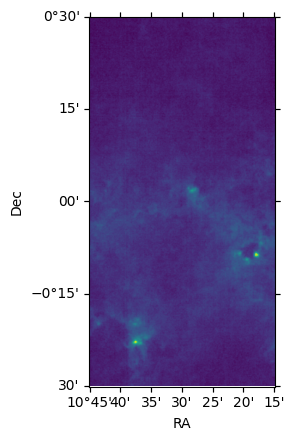

In [27]:
wcs_3d = WCS(data_3D[0].header.copy())
wcs_3d_c = wcs_3d.celestial
fig = plt.figure()
fig.add_subplot(111, projection=wcs_3d_c)
plt.imshow(data_3D[0].data.sum(axis=0), origin='lower', cmap=plt.cm.viridis)
plt.xlabel('RA')
plt.ylabel('Dec')
corners_world = wcs_3d_c.calc_footprint()
min_ra, min_dec = corners_world.min(axis=0)
max_ra, max_dec = corners_world.max(axis=0)
data_s2_wcs = WCS(data_spine[0].header)
# Find these corners inside 2D mask data
min_pix_x, min_pix_y = data_s2_wcs.world_to_pixel_values(min_ra, min_dec)
max_pix_x, max_pix_y = data_s2_wcs.world_to_pixel_values(max_ra, max_dec)
min_pix_x, max_pix_x = int(min_pix_x), int(max_pix_x)
min_pix_y, max_pix_y = int(min_pix_y), int(max_pix_y)

(336, 205)


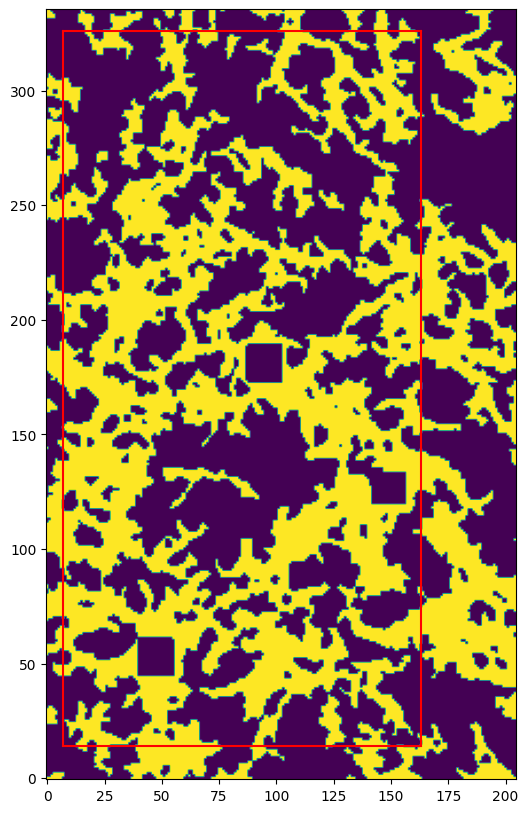

In [32]:
print(data_spine[0].data.shape)
wcs_2d = WCS(data_spine[0].header.copy())
plt.figure(figsize=(10, 10))
plt.imshow(data_spine[0].data, origin='lower')
corners_world = wcs_3d_1_r.calc_footprint()
min_ra, min_dec = corners_world.min(axis=0)
max_ra, max_dec = corners_world.max(axis=0)

# Find these corners inside 2D mask data data_s2_wcs
min_pix_x, min_pix_y = wcs_2d.world_to_pixel_values(min_ra, min_dec)
max_pix_x, max_pix_y = wcs_2d.world_to_pixel_values(max_ra, max_dec)
min_pix_x, max_pix_x = int(min_pix_x), int(max_pix_x)
min_pix_y, max_pix_y = int(min_pix_y), int(max_pix_y)
plt.plot([min_pix_x, max_pix_x ], [min_pix_y, min_pix_y], 'r')
plt.plot([min_pix_x, min_pix_x], [min_pix_y, max_pix_y], 'r')
plt.plot([max_pix_x, max_pix_x ], [max_pix_y, min_pix_y], 'r')
plt.plot([max_pix_x, min_pix_x], [max_pix_y, max_pix_y], 'r')


In [51]:
# Dimensions
ny_cube, nx_cube = data_reproject[0].data.shape[-2:]
wcs_cube = WCS(data_reproject[0].header).celestial
# Coordonnées pixel du cube dans son propre WCS
x_cube = np.array([0, nx_cube])
y_cube = np.array([0, ny_cube])

# Convertir ces coins en coordonnées monde (GLON, GLAT)
lon, lat = wcs_cube.all_pix2world(x_cube, y_cube, 1)
print("lon, lat", lon, lat)
# Puis convertir ces coins dans le WCS du spine
x_spine, y_spine = wcs_2d.all_world2pix(lon, lat, 1)
print("x_spine, y_spine", x_spine, y_spine)
# Déterminer les bornes
x_min = int(np.floor(min(x_spine)))
x_max = int(np.ceil(max(x_spine)))
y_min = int(np.floor(min(y_spine)))
y_max = int(np.ceil(max(y_spine)))

lon, lat [10.75513891 10.25361113] [-0.50472222  0.49513889]
x_spine, y_spine [  7. 164.] [ 15. 328.]


In [34]:
x_min, x_max, y_min, y_max

(7, 165, 14, 328)

Découpe du spine : x=(7,165), y=(14,328)
data_spine shape (336, 205)
cut shape (313, 157)
origin reproject shape (313, 157)
 [min_pix_y, max_pix_y, max_pix_y-min_pix_y], [min_pix_x, max_pix_x , -max_pix_x+min_pix_x] [14, 326, 312] [163, 7, 156]


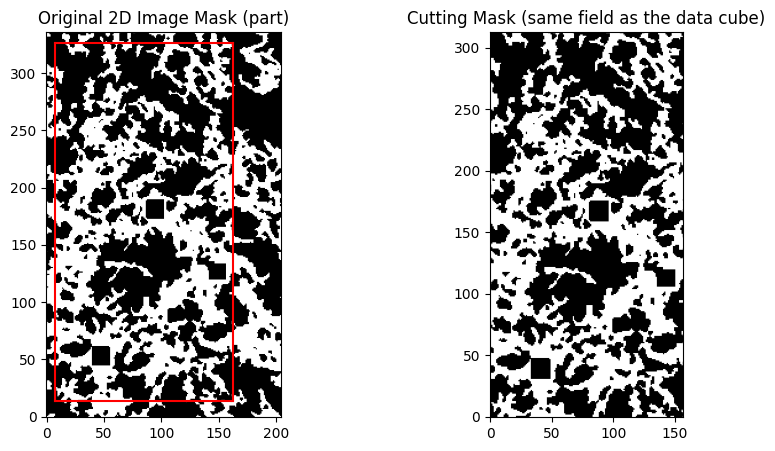

In [35]:

print(f"Découpe du spine : x=({x_min},{x_max}), y=({y_min},{y_max})")

# Appliquer la découpe
print("data_spine shape", data_spine[0].data.shape)
data_spine_cut = data_spine[0].data[y_min:y_max-1, x_min:x_max-1]
print("cut shape", data_spine_cut.shape)
print("origin reproject shape", data_reproject[0].data.shape[-2:])
print (" [min_pix_y, max_pix_y, max_pix_y-min_pix_y], [min_pix_x, max_pix_x , -max_pix_x+min_pix_x]", [min_pix_y, max_pix_y,max_pix_y-min_pix_y],  [min_pix_x, max_pix_x , -max_pix_x+min_pix_x])
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))
plt.subplot(1,2,1)
plt.imshow(data_spine[0].data, origin='lower', cmap='gray')
plt.plot([min_pix_x, max_pix_x ], [min_pix_y, min_pix_y], 'r')
plt.plot([min_pix_x, min_pix_x], [min_pix_y, max_pix_y], 'r')
plt.plot([max_pix_x, max_pix_x ], [max_pix_y, min_pix_y], 'r')
plt.plot([max_pix_x, min_pix_x], [max_pix_y, max_pix_y], 'r')
plt.title("Original 2D Image Mask (part)")
plt.subplot(1,2,2)
plt.imshow(data_spine_cut, origin='lower', cmap='gray')
plt.title("Cutting Mask (same field as the data cube)")
plt.show()

## 2.1  ske_label

In [36]:
base = "../../../BIGSF_DATA/Clustering_COHRS/data_test8"
print(base)
indices = range(26)
found = []
missing = []

i_skeleton = 0
ske_data = None
path = os.path.join(base, f"skeleton_{i_skeleton}", "3d_skeletons.fits")
if not os.path.exists(path):
    missing.append(i_skeleton)
    print(f"{path} opened but primary data is None.")
try:
    with fits.open(path) as hdul:
        ske_data = hdul[0].data
        ske_wcs = WCS(hdul[0].header)
        if ske_data is None:
            print(f"{path} opened but primary data is None.")
            missing.append(i_skeleton)
        # sum along axis 0 to 2D
    found.append((i_skeleton, ske_data))
except Exception as e:
    print(f"Erreur en ouvrant {path}: {e}")
    missing.append(i_skeleton)
#ske_data = ske_data[:, :, ::-1]
print("missing ", missing)
#cprint("found ", found)
z_s , y_s , x_s = np.where(ske_data > 0)
print(" z_s ", z_s.min())
x_s , y_s = wcs_cube.all_pix2world(x_s, y_s, 1)

z_s = v_vals[z_s]
#z_s = (z_s - (ske_wcs.wcs.crpix[2] - 1)) * ske_wcs.wcs.cdelt[2] + ske_wcs.wcs.crval[2]
print(" z_s ", z_s.min())
ske_label = ske_data[ske_data > 0]
labels = np.unique(ske_label)
labels = labels[labels > 0]  # exclure fond (0)
print(f"{len(labels)} labels trouvés dans le squelette.")


../../../BIGSF_DATA/Clustering_COHRS/data_test8
missing  []
 z_s  286
 z_s  -18.308083562997297
6 labels trouvés dans le squelette.


In [41]:
import plotly.graph_objects as go
import numpy as np
import plotly.io as pio
import plotly.colors as pc
pio.renderers.default = "browser"

cube = data_reproject[0].data
cube = np.nan_to_num(cube, nan=0.0)
threshold = np.percentile(cube, 99.0)
z, y, x = np.where(cube > threshold)
x , y = wcs_cube.all_pix2world(x, y, 1)
z = v_vals[z]
values = cube[cube > threshold]

proj = data_spine_cut[data_spine_cut > 0]
y2d, x2d  = np.where(data_spine_cut > 0)
x2d, y2d = wcs_cube.all_pix2world(x2d, y2d, 1)


mean_velocity = np.linspace(0, 1, len(labels)+1)
ske_data_transform = ske_data.copy()
opacity = np.zeros_like(cube, dtype=float)

for i, lab in enumerate(labels):
    mask_label = ske_data == lab
    max_z_label = np.nanmax(np.where(mask_label, data_reproject[0].data, np.nan), axis=0)
    min_z_label = np.nanmin(np.where(mask_label, data_reproject[0].data, np.nan), axis=0)
    normalized = np.zeros_like(data_reproject[0].data, dtype=float)
    z_idx, y_idx, x_idx = np.where(mask_label)
    mean_velocity[i] = v_vals[z_idx].mean()
    normalized[z_idx, y_idx, x_idx] = (data_reproject[0].data[z_idx, y_idx, x_idx] - min_z_label[y_idx, x_idx])/ (max_z_label[y_idx, x_idx] - min_z_label[y_idx, x_idx])
    opacity += normalized
setp = 10
mean_velocity[len(labels)] = mean_velocity.max() + setp

#palette  = pc.qualitative.Set3Plotly3_r
vertor_one = np.linspace(0, 1, len(labels)+1)
vertor_one = vertor_one[mean_velocity.argsort().argsort()]
palette = pc.sample_colorscale('tempo_r', vertor_one)
label_to_color = {lab: palette[i] for i, lab in enumerate(labels)}
#colors_for_points = [palette[np.where(labels==lab)[0][0]] for lab in ske_label]
colors_for_points = [label_to_color[lab] for lab in ske_label]

/tmp/ipykernel_94845/250039384.py:26: RuntimeWarning:

All-NaN slice encountered

/tmp/ipykernel_94845/250039384.py:27: RuntimeWarning:

All-NaN slice encountered

/tmp/ipykernel_94845/250039384.py:31: RuntimeWarning:

invalid value encountered in divide



### 2.3. 3d plot to check

In [300]:
import plotly.graph_objects as go
import numpy as np
import plotly.io as pio
import plotly.colors as pc
pio.renderers.default = "browser"

cube = data_reproject[0].data
cube = np.nan_to_num(cube, nan=0.0)
threshold = np.percentile(cube, 99.7)
z, y, x = np.where(cube > threshold)
x , y = wcs_cube.all_pix2world(x, y, 1)
z = v_vals[z]
values = cube[cube > threshold]

proj = data_spine_cut[data_spine_cut > 0]
y2d, x2d  = np.where(data_spine_cut > 0)
x2d, y2d = wcs_cube.all_pix2world(x2d, y2d, 1)

true_palette = pc.sample_colorscale('tempo_r', np.linspace(0, 1, len(labels)+1))

lemin_long = np.min( [x.min(), x.max(), x_s.min(), x_s.max(), x2d.min(), x2d.max() ] )
lemax_long = np.max( [x.min(), x.max(), x_s.min(), x_s.max(), x2d.min(), x2d.max() ] )
lemin_lat = np.min( [y.min(), y.max(), y_s.min(), y_s.max(), y2d.min(), y2d.max() ] )
lemax_lat = np.max( [y.min(), y.max(), y_s.min(), y_s.max(), y2d.min(), y2d.max() ] )
lemin_vit = np.min( [ z_s.min(), z_s.max() ] )
lemax_vit = np.max( [ z_s.min(), z_s.max() ] )
#lemax_vit = lemin_vit + labels.shape[0]
fig = go.Figure()

fig.add_trace(go.Scatter3d(
    x=x2d.flatten(),
    y=y2d.flatten(),
    z=np.zeros_like(x2d.flatten(), dtype=int) + lemin_vit ,
    mode='markers',
    marker=dict(symbol='square',
        size=2,
        color=proj.flatten(),
        colorscale='gray',
        opacity=0.6,
        line = dict ( color = 'gray' , width = 2 ) ,
    ),
    name="mask 2d"
))

for i, label in enumerate(labels):
    mask = ske_label == label
    x_i, y_i, z_i = x_s[mask], y_s[mask], z_s[mask]
    z_mean = z_i.mean()
    if i == 0:
        p = true_palette
        n_ticks = len(labels)
        tickvals = np.linspace(0, 1, len(labels))
        ticktext = [f"{v:.0f}" for v in np.sort(mean_velocity)]
        b = dict(title="Velocity (km/s)", orientation='h', len=0.45,  x=0.5, y=-0.2, thickness=12,  tickvals=tickvals,ticktext=ticktext, tickmode='array'
            )# tickvals=tickvals,, tickmode='array'
        fig.add_trace(go.Scatter3d(
            x=x_i, y=y_i, z=np.zeros(x_i.shape, dtype=int) + mean_velocity[i],
            mode='markers',
            marker=dict(symbol='square',
                size=3,
                color=palette[i],
                cmin=0,cmax=1,
                opacity=0.8,
                colorscale=p,
                colorbar=b,
            ),
            line = dict ( color = palette[i] , width = 2 ) ,
            name=f'2d Skeleton_{i_skeleton}_{int(label)}'
        ))
    else:
        fig.add_trace(go.Scatter3d(
            x=x_i, y=y_i, z=np.zeros(x_i.shape, dtype=int) + mean_velocity[i],
            mode='markers',
            marker=dict(symbol='square',
                size=3,
                color=palette[i],
                cmin=0,cmax=1,
                opacity=0.8,
            ),
            line = dict ( color = palette[i] , width = 2 ) ,
            name=f'2d Skeleton_{i_skeleton}_{int(label)}'
        ))

fig.update_layout(
    scene=dict(
        xaxis_title='Galactic Longitude (deg)',
        yaxis_title='Galactic Latitude (deg)',
        zaxis_title='Velocity (km/s)',
        xaxis=dict(range=[lemin_long, lemax_long], backgroundcolor="rgba(0,0,0,0)"),
        yaxis=dict(range=[lemin_lat, lemax_lat],backgroundcolor="rgba(0,0,0,0)"),
        zaxis=dict(range=[lemin_vit, lemax_vit],backgroundcolor="rgba(0,0,0,0)" ),
        aspectmode='manual',
        aspectratio=dict(x=1.1, y=1.1, z=0.8)
    ),
    margin=dict(l=0, r=0, b=0, t=30),
    showlegend=True,
    title="3D Cube Visualization"
)


# range=[x.min(), x.max()], range=[y_s.min(), y.max()], ange=[z.min(), z.max()],
fig.show()
fig.write_html(f"figures/mask3d8_ske{i_skeleton}.html")


### 2 4 MASK plot

In [301]:
import plotly.graph_objects as go
import numpy as np
import plotly.io as pio
import plotly.colors as pc
pio.renderers.default = "browser"

cube = data_reproject[0].data
cube = np.nan_to_num(cube, nan=0.0)
threshold = np.percentile(cube, 99.7)
z, y, x = np.where(cube > threshold)
x , y = wcs_cube.all_pix2world(x, y, 1)
z = v_vals[z]
values = cube[cube > threshold]

proj = data_spine_cut[data_spine_cut > 0]
y2d, x2d  = np.where(data_spine_cut > 0)
x2d, y2d = wcs_cube.all_pix2world(x2d, y2d, 1)


lemin_long = np.min( [x.min(), x.max(), x_s.min(), x_s.max(), x2d.min(), x2d.max() ] )
lemax_long = np.max( [x.min(), x.max(), x_s.min(), x_s.max(), x2d.min(), x2d.max() ] )
lemin_lat = np.min( [y.min(), y.max(), y_s.min(), y_s.max(), y2d.min(), y2d.max() ] )
lemax_lat = np.max( [y.min(), y.max(), y_s.min(), y_s.max(), y2d.min(), y2d.max() ] )
lemin_vit = np.min( [ z_s.min(), z_s.max() ] )
lemax_vit = np.max( [ z_s.min(), z_s.max() ] )

fig = go.Figure()
fig.add_trace(go.Scatter(
    x=x2d.flatten(),
    y=y2d.flatten(),
    mode='markers',
    marker=dict(symbol= "square",
        size=2,
        color=proj.flatten(),
        colorscale='gray',
        opacity=0.6,
        line = dict ( color = 'gray' , width = 2 ) ,
    ),
    name="unet 2d mask"
))

for i, label in enumerate(labels):
    mask = ske_label == label
    x_i, y_i, z_i = x_s[mask], y_s[mask], z_s[mask]
    velotcy_i = f"{mean_velocity[i]:.0f}"
    if i == len(labels)-1:
        p = true_palette
        tickvals = np.linspace(0, 1, len(labels))
        ticktext = [f"{v:.0f}" for v in np.sort(mean_velocity)]
        b = dict(title="Velocity (km/s)", orientation='v', len=0.6,  x=1.0, y=0.4, thickness=20,
            tickvals=tickvals,
            ticktext =ticktext) # y=-0.2,
        fig.add_trace(go.Scatter(
            x=x_i, y=y_i,
            mode='markers',
            marker=dict(symbol= "square",
                size=8,cmin=0,cmax=1,
                color=palette[i],
                opacity=0.6,
                colorscale=p,
                colorbar=b,
            ),
            line = dict ( color = palette[i] , width = 2 ) ,
            name=f'2dSkeleton_{i_skeleton}_{velotcy_i}'
        ))
    else:
        fig.add_trace(go.Scatter(
            x=x_i, y=y_i,
            mode='markers',
            marker=dict(symbol= "square",
                size=8,cmin=0,cmax=1,
                color=palette[i],
                opacity=0.6,
            ),
            line = dict ( color = palette[i] , width = 2 ) ,
            name=f'2dSkeleton_{i_skeleton}_{velotcy_i}'
        ))

fig.update_layout(
    legend=dict(
        title="Clusters",
        orientation="v",       # "h" pour horizontale
        x=1.0,                # Position horizontale (0 = bord gauche, 1 = bord droit)
        y=1,                   # Position verticale (0 = bas, 1 = haut)
        xanchor="left",        # ancre sur le côté gauche
        yanchor="top",
        bgcolor="rgba(255,255,255,0.7)",  # fond translucide
        bordercolor="lightgray",
        borderwidth=1
    ),
    xaxis=dict(
        title='Galactic Longitude (deg)',
        zeroline=True,
        zerolinecolor='black',
        showgrid=True,
        gridcolor='lightgray',
        range=[lemin_long, lemax_long],
        constrain='domain', ticklabelposition="outside top",
    ),
    yaxis=dict(
        title='Galactic Latitude (deg)',
        zeroline=True,
        zerolinecolor='black',
        showgrid=True,
        gridcolor='lightgray',
        range=[lemin_lat, lemax_lat],
        scaleanchor="x",ticklabelposition="outside left",
        scaleratio=0.6
    ),
    width=900,
    height=700,
    paper_bgcolor='white',
    plot_bgcolor='white',
    margin=dict(l=80, r=50, b=80, t=60),
    showlegend=True,
    title=dict(text="2D Map of Fillaments from Unet Clustering", x=0.5, xanchor='center'),
)

fig.show()
fig.write_html(f"figures/d2figure8_ske{i_skeleton}.html")
#fig.write_image(f"figures/d2figure8_ske{i_skeleton}.png", width=1800, height=1400, scale=2)

In [302]:
print(x_s.min() , x_s.max(), y_s.min(),  y_s.max())
print(x.min() , x.max(), y.min(),  y.max())
print(x2d.min() , x2d.max(), y2d.min(),  y2d.max())
print(z_s.min() , z_s.max())
print(z.min() , z.max())
print(f"Longitude range: {l_vals.min():.2f} → {l_vals.max():.2f} deg")
print(f"Latitude range:  {b_vals.min():.2f} → {b_vals.max():.2f} deg")
print(f"Velocity range:  {v_vals.min():.2f} → {v_vals.max():.2f} km/s")

10.256311449713998 10.751453594052496 -0.5037110470736326 0.48975926213836934
10.256311411265786 10.751454008562902 -0.503712765680486 0.48976140622371933
10.256309950210365 10.75464832422804 -0.5069075393492394 0.48976211206297837
-18.308083562997297 152.5069164370027
-27.833083562997302 153.77691643700268
Longitude range: 10.25 → 10.75 deg
Latitude range:  -0.50 → 0.49 deg
Velocity range:  -199.92 → 299.83 km/s


## FIGURE SUPERPOSITION WITH OPACITY VARIATION

In [303]:
z_idx, y_idx, x_idx = np.where(ske_data > 0)
op_i = opacity[z_idx, y_idx, x_idx]
x_i, y_i = wcs_cube.all_pix2world(x_idx, y_idx, 1)
z_i = v_vals[z_idx]
# Scatter3D avec la valeur d'opacité représentée en couleur
fig = go.Figure()

fig.add_trace(go.Scatter3d(
    x=x_i,
    y=y_i,
    z=z_i,
    mode='markers',
    marker=dict(
        size=3,
        color=op_i,           # couleur = valeur d'opacité
        colorscale='Viridis', # colormap pour visualiser l’opacité
        opacity=0.8,
        colorbar=dict(title='Opacity')
    )
))

fig.update_layout(
    scene=dict(
        xaxis_title='Galactic Longitude (deg)',
        yaxis_title='Galactic Latitude (deg)',
        zaxis_title='Velocity (km/s)',
        xaxis=dict(range=[lemin_long, lemax_long], backgroundcolor="rgba(0,0,0,0)"),
        yaxis=dict(range=[lemin_lat, lemax_lat],backgroundcolor="rgba(0,0,0,0)"),
        zaxis=dict(range=[lemin_vit, lemax_vit-20],backgroundcolor="rgba(0,0,0,0)" ),
        aspectmode='manual',
        aspectratio=dict(x=1.1, y=1.1, z=1)
    ),
    margin=dict(l=0, r=0, b=0, t=30),
    showlegend=True,
    title=f"3D Cube Visualization"
)

fig.show()

## 2.6 Plot supperposition avec opacity SCATTER

In [304]:
## 2.6 Plot supperposition avec opacity SCATTER
fig = go.Figure()

tickvals_cube = np.linspace(np.log(min(values)), np.log(max(values)), 5)
ticktext_cube = [f"{np.exp(v):.2f}" for v in tickvals_cube]
fig.add_trace(go.Scatter3d(
    x=x, y=y, z=z,
    mode='markers',
    marker=dict(
        size=3,
        color=np.log(values),
        colorscale='Turbo',
        opacity=0.3,
        showscale=True,
        colorbar=dict(
            title='Temperature (K)',
            tickvals=tickvals_cube, ticktext=ticktext_cube,
            orientation='h',
            xanchor='center',
            len=0.7,
            thickness=15,
            x=0.5,
            y=0.9,
        ),
    ),
    name='data cube'
))
fig.add_trace(go.Scatter3d(
    x=x2d.flatten(),
    y=y2d.flatten(),
    z=np.zeros_like(x2d.flatten(), dtype=int) + np.min(z) ,
    mode='markers',
    marker=dict(
        size=3,
        color=proj.flatten(),
        colorscale='gray',
        opacity=0.8
    ),
    name="Unet mask 2d"
))

bins = np.linspace(0, 1, 5)
p = true_palette
n_ticks = len(labels)
tickvals = np.linspace(0, 1, len(labels)+1)
ticktext = [f"{v:.0f}" for v in np.sort(mean_velocity)]
b = dict(title="Velocity (km/s)", orientation='v', len=0.5,  x=1.0, y=0.09,
    thickness=20, tickvals=tickvals, ticktext=ticktext)
for i, label in enumerate(labels):
    pi = None
    bi = None
    velotcy_i = f"{mean_velocity[i]:.0f}"
    group_name = f"skeleton V:{velotcy_i}"
    z_idx, y_idx, x_idx = np.where(ske_data == label)
    op_i = opacity[z_idx, y_idx, x_idx]
    x_i, y_i = wcs_cube.all_pix2world(x_idx, y_idx, 1)
    z_i = v_vals[z_idx]
    pi = p
    bi = b
    for j in range(1, len(bins)-1):
        sel = (op_i >= bins[j]) & (op_i < bins[j+1])
        if np.any(sel):
            fig.add_trace(go.Scatter3d(
                x=x_i[sel], y=y_i[sel], z=z_i[sel],
                mode='markers',
                marker=dict(
                    size=4,
                    color=palette[i],
                    opacity=float(bins[j+1])
                ),
                name=f"Skeleton V={velotcy_i}",
                legendgroup=group_name,
                showlegend=(j == 3)
            ))
    fig.add_trace(go.Scatter3d(
        x=x_i, y=y_i, z=np.zeros(x_i.shape, dtype=int) + np.min(z) ,
        mode='markers',
        marker=dict(symbol='square',
            size=3,
            color=palette[i], cmin=0, cmax=1,
            opacity=0.8,
            colorscale=pi,
            colorbar=bi,
        ),
        name=f'2dSkeleton V: {velotcy_i}',
        showlegend=True
    ))

lemin_long = np.min( [x.min(), x.max(), x_s.min(), x_s.max(), x2d.min(), x2d.max() ] )
lemax_long = np.max( [x.min(), x.max(), x_s.min(), x_s.max(), x2d.min(), x2d.max() ] )
lemin_lat = np.min( [y.min(), y.max(), y_s.min(), y_s.max(), y2d.min(), y2d.max() ] )
lemax_lat = np.max( [y.min(), y.max(), y_s.min(), y_s.max(), y2d.min(), y2d.max() ] )
lemin_vit = np.min( [z.min(), z.max(), z_s.min(), z_s.max() ] )
lemax_vit = np.max( [z.min(), z.max(), z_s.min(), z_s.max() ] )   #-35
scene_radec = {'center': {'x': 0, 'y': 0.9, 'z': 0}, 'eye': {'x': -1.0, 'y': -1.8, 'z': 0.1},
               'up': {'x': 0, 'y': 0, 'z': -0.1}}
fig.update_layout(
    legend=dict(
        title=f"Clusters {i_skeleton}",
        orientation="v",
        x=1.0,
        y=1.04,
        xanchor="left",
        yanchor="top",
        bgcolor="rgba(255,255,255,0.7)",
        bordercolor="lightgray",
        borderwidth=1
    ),
    scene=dict(
        xaxis_title='Galactic Longitude (deg)',
        yaxis_title='Galactic Latitude (deg)',
        zaxis_title='Velocity (km/s)',
        xaxis=dict(showgrid=True, gridcolor='lightgray', zeroline=True,
            zerolinecolor='black',  range=[lemin_long, lemax_long], backgroundcolor="rgba(0,0,0,0)"),
        yaxis=dict(showgrid=True, gridcolor='lightgray', zeroline=True,
            zerolinecolor='black', range=[lemin_lat, lemax_lat],backgroundcolor="rgba(0,0,0,0)"),
        zaxis=dict(showgrid=True, gridcolor='lightgray', zeroline=True,
            zerolinecolor='black', range=[lemin_vit, lemax_vit],backgroundcolor="rgba(0,0,0,0)" ),
        bgcolor='white',
        aspectmode='manual',
        aspectratio=dict(x=1.1, y=1.1, z=1)
    ),
    margin=dict(l=80, r=50, b=80, t=60),
    showlegend=True,
    scene_camera=scene_radec,
    width=900,
    height=700,
    paper_bgcolor='white',
    plot_bgcolor='white',
    title=dict(text=f"3D Map of Fillaments from Unet Clustering{i_skeleton}", x=0.5, xanchor='center'),
)

# range=[x.min(), x.max()], range=[y_s.min(), y.max()], ange=[z.min(), z.max()],
fig.show()
fig.write_html(f"figures/figure8opacyty_ske{i_skeleton}.html")

### SURFACE PLOT

In [305]:
import numpy as np
from scipy.interpolate import griddata
import plotly.graph_objects as go
lemin_long = np.min( [x.min(), x.max(), x_s.min(), x_s.max(), x2d.min(), x2d.max() ] )
lemax_long = np.max( [x.min(), x.max(), x_s.min(), x_s.max(), x2d.min(), x2d.max() ] )
lemin_lat = np.min( [y.min(), y.max(), y_s.min(), y_s.max(), y2d.min(), y2d.max() ] )
lemax_lat = np.max( [y.min(), y.max(), y_s.min(), y_s.max(), y2d.min(), y2d.max() ] )
lemin_vit = np.min( [z.min(), z.max(), z_s.min(), z_s.max() ] )
lemax_vit = np.max( [z.min(), z.max(), z_s.min(), z_s.max() ] )   #-35
xrange = [lemin_long-0.002, 10.51]
yrange = [-.33, -0.05]
zrange = [lemin_vit, lemax_vit-60]
# lemax_vit-60 463

z1, y1, x1 = np.where(cube > threshold)
x1 , y1 = wcs_cube.all_pix2world(x1, y1, 1)
z1 = v_vals[z1]

values = cube[cube > threshold]
x_ii = np.linspace(x1.min(), x1.max(), 60)
y_ii = np.linspace(y1.min(), y1.max(), 60)
z_ii = np.linspace(z1.min(), z1.max(), 60)
X, Y, Z = np.meshgrid(x_ii, y_ii, z_ii, indexing='ij')

# Interpoler les valeurs sur la grille
points = np.vstack((x1, y1, z1)).T
grid_values = griddata(points, np.log(values), (X, Y, Z), method='linear', fill_value=0) #np.log(values)


### 2.7 Plot supperposition avec opacity and Volume

In [338]:
### 2.7 Plot supperposition avec opacity and Volume
fig = go.Figure()
tickvals_cube = np.linspace(np.log(min(values)), np.log(max(values)), 8)
ticktext_cube = [f"{np.exp(v):.2f}" for v in tickvals_cube]

fig.add_trace(go.Volume(
    x=X.flatten(),
    y=Y.flatten(),
    z=Z.flatten(),
    value=grid_values.flatten(),
    isomin=np.nanmin(np.log(values))+0.083,
    isomax=np.nanmax(np.log(values))-1.2,
    opacity=0.8,
    surface_count=20,
    colorscale='Turbo',
    opacityscale="max",
    caps=dict(
        x_show=True,
        y_show=True,
        z_show=True,
        x_fill=1,
    ),
    colorbar=dict(
        title='Temperature (K)',
        tickvals=tickvals_cube, ticktext=ticktext_cube,
        orientation='h',
        xanchor='center',
        len=0.7,
        thickness=15,
        x=0.5,
        y=0.9,
    ),
    showlegend=True,
    showscale=True,
    name='data cube'
))

fig.add_trace(go.Scatter3d(
    x=x2d.flatten(),
    y=y2d.flatten(),
    z=np.zeros_like(x2d.flatten(), dtype=int) + np.min(z) ,
    mode='markers',
    marker=dict(symbol='square',
        size=3,
        color=proj.flatten(),
        colorscale='gray',
        opacity=0.6
    ),
    name="Unet 2d mask"
))

bins = np.linspace(0, 1, 5)
p = true_palette
n_ticks = len(labels)
tickvals = np.linspace(0, 1, len(labels)+1)
ticktext = [f"{v:.0f}" for v in np.sort(mean_velocity)]
b = dict(title="Velocity (km/s)", orientation='v', len=0.5,  x=1.0, y=0.2,
    thickness=20, tickvals=tickvals, ticktext=ticktext)
for i, label in enumerate(labels):
    pi = None
    bi = None
    velotcy_i = f"{mean_velocity[i]:.0f}"
    group_name = f"skeleton V:{velotcy_i}"
    z_idx, y_idx, x_idx = np.where(ske_data == label)
    op_i = opacity[z_idx, y_idx, x_idx]
    x_i, y_i = wcs_cube.all_pix2world(x_idx, y_idx, 1)
    z_i = v_vals[z_idx]
    #if i == len(labels)-1:
    pi = p
    bi = b # z_i[sel] np.zeros(x_i[sel].shape, dtype=int) + mean_velocity[i]
    for j in range(1, len(bins)-1):
        sel = (op_i >= bins[j]) & (op_i < bins[j+1])
        if np.any(sel):
            fig.add_trace(go.Scatter3d(
                x=x_i[sel], y=y_i[sel], z=z_i[sel],
                mode='markers',
                marker=dict(
                    size=3,
                    color=palette[i],
                    opacity=float(bins[j+1])
                ),
                name=f"Skeleton V={velotcy_i}",
                legendgroup=group_name,
                showlegend=(j == 3)
            ))
    fig.add_trace(go.Scatter3d(
        x=x_i, y=y_i, z=np.zeros(x_i.shape, dtype=int) + np.min(z) ,
        mode='markers',
        marker=dict(symbol='square',
            size=3,
            color=palette[i], cmin=0, cmax=1,
            opacity=0.8,
            colorscale=pi,
            colorbar=bi,
        ),
        name=f'2dSkeleton V: {velotcy_i}',
        showlegend=True
    ))

scene_radec = {'center': {'x': 0.4, 'y': 0.7, 'z': 0.0}, 'eye': {'x': -0.8, 'y': -1.8, 'z': 0.0},
               'up': {'x': 0, 'y': 0, 'z': -0.7}}

fig.update_layout(
    legend=dict(
        title=f"Clusters {i_skeleton}",
        orientation="v",
        x=1.0,
        y=1.05,
        xanchor="left",
        yanchor="top",
        bgcolor="rgba(255,255,255,0.7)",
        bordercolor="lightgray",
        borderwidth=1,
    ),
    scene=dict(
        bgcolor='white',
        aspectmode='manual',
        aspectratio=dict(x=1.1, y=1.1, z=1),
        xaxis_title='Galactic Longitude (deg)',
        yaxis_title='Galactic Latitude (deg)',
        zaxis_title='Velocity (km/s)',
        xaxis=dict(showgrid=True, gridcolor='lightgray', zeroline=True, zerolinecolor='black', range=[lemin_long-0.002, 10.51], backgroundcolor="rgba(0,0,0,0)"), #lemax_long
        yaxis=dict(showgrid=True, gridcolor='lightgray', zeroline=True,
                   zerolinecolor='black', range=[-.33, -0.05],backgroundcolor="rgba(0,0,0,0)"), #lemax_lat lemin_lat
        zaxis=dict(showgrid=True, gridcolor='lightgray', zeroline=True,
                   zerolinecolor='black', range=[lemin_vit, lemax_vit-60],backgroundcolor="rgba(0,0,0,0)" )
    ),
    scene_camera=scene_radec,
    margin=dict(l=80, r=50, b=60, t=60),
    showlegend=True,
    width=900,
    height=700,
    paper_bgcolor='white',
    plot_bgcolor='white',
    title=dict(text=f"3D Map of Fillaments from Unet Clustering{i_skeleton}", x=0.5, xanchor='center'),
)

# range=[x.min(), x.max()], range=[y_s.min(), y.max()], ange=[z.min(), z.max()],
fig.show()
fig.write_html(f"figures/figure8volume2-z60_ske{i_skeleton}.html")

# ------------------------------------------------------------------

## IMAGE ANNIE

In [76]:
v_vals.shape

(788,)

/tmp/ipykernel_94845/2288442977.py:51: RuntimeWarning:

invalid value encountered in divide



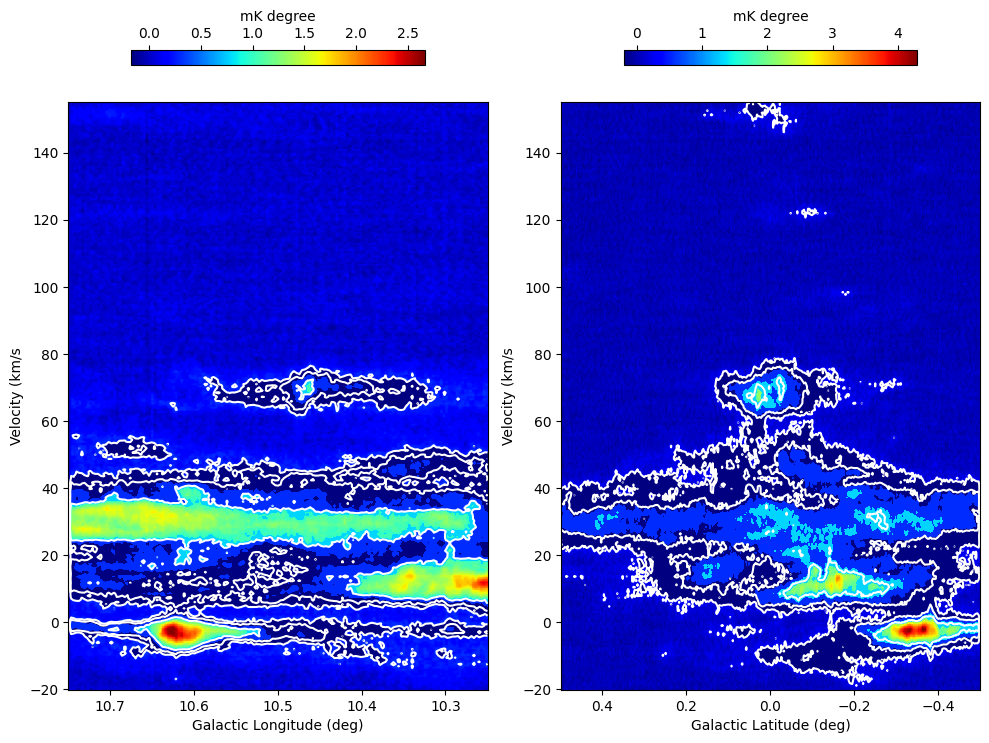

In [91]:
%matplotlib inline
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
from matplotlib import cm
from mpl_toolkits.mplot3d import Axes3D
from astropy.io import fits

# === Lecture du moment-0 map ===
iz_min = np.where(v_vals >= z_s.min()-2)[0][0]
iz_max = np.where(v_vals >= z_s.max()+2 )[0][0]
zmin = v_vals[iz_min]
zmax = v_vals[iz_max]
cube = data_reproject[0].data[iz_min:iz_max, ::-1,:]# iz_min:iz_max
cube = np.nan_to_num(cube, nan=0.0)
threshold = np.percentile(cube, 99.7)
z, y, x = np.where(cube > threshold)
corners_world = wcs_3d_c.calc_footprint()
min_ra, min_dec = corners_world.min(axis=0)
max_ra, max_dec = corners_world.max(axis=0)
corners_world

x , y = wcs_cube.all_pix2world(x, y, 1)
#z = v_vals[z]
values = cube[cube > threshold]
nz, ny, nx = cube.shape

xmin, xmax = min_ra, max_ra
ymin, ymax = min_dec, max_dec
# === Coordonnées spatiales ===

# grille de coordonnées
ra = np.linspace( xmax, xmin,nx)
dec = np.linspace( ymax,ymin, ny)
vitesse = np.linspace(zmin, zmax, nz)
X1 , Z1 = np.meshgrid(ra, vitesse)
Y2 , Z2 = np.meshgrid(dec, vitesse)
X, Y = np.meshgrid(ra, dec)
#X, Y = np.meshgrid(x, y)
#data2d = cube[iz_min:iz_max,:,:].sum(axis=1)
#cube_reduit = cube[iz_min:iz_max,:,:]
# === Coordonnées 3D du cube ===
# l1, b1, and velocity1 are obtained from the pixel-by-pixel fitting of the 3D data cube using SCOUSEPY, where velocity1 is the centroid velocity.
j_cmap = cm.jet
l1 = x_s
b1 = y_s
velocity1 = z_s
# levels = np.linspace(values.min(), values.max(), 10)

mask = cube > threshold
mean_above_a0 = np.nan_to_num(np.nansum(cube * mask, axis=0) / np.nansum(mask, axis=0), 0.0)
#mean_above_a0 = np.nanmean(cube, axis=0)
mean_above_a1 = np.nanmean(cube, axis=1)
mean_above_a2 = np.nanmean(cube, axis=2)
#mean_above_a0 = np.nansum(cube * mask, axis=0) / np.nansum(mask, axis=0)
levels1 = np.linspace(np.min(mean_above_a1)+0.5, np.max(mean_above_a1)-1.7, 8)
levels2 = np.linspace(np.min(mean_above_a2)+0.5, np.max(mean_above_a2)-2.5, 8)
e_extent1 = [xmin,  xmax, zmin, zmax]
e_extent1_bis = [ xmax, xmin, zmin, zmax]
e_extent2 = [ymax, ymin,  zmin, zmax]
levels = np.linspace(np.min(mean_above_a0+zmin), np.max(mean_above_a0+zmin), 10)
# === Figure ===
fig = plt.figure(figsize=(10, 10))
ax1 = fig.add_subplot(121)
norm = cm.colors.Normalize(vmax=mean_above_a1.max()-1.3, vmin=-mean_above_a1.min()+0.45)
cset1 = ax1.contourf(X1, Z1, mean_above_a1, levels=levels1, norm=norm,
    cmap=j_cmap.resampled(len(levels1) -1))
cset21 = ax1.contour(X1, Z1, mean_above_a1, levels=cset1.levels[[0, 2, 6]], colors='w',  origin='lower', extent=e_extent1_bis)
cset21.set_linestyle('solid')
im1 = ax1.imshow(mean_above_a1, extent=e_extent1_bis, aspect=0.004, origin='lower',  cmap=j_cmap)#extent=e_extent1, aspect=0.004,
ax1.set_xlabel('Galactic Longitude (deg)')
ax1.set_ylabel('Velocity (km/s')
#ax1.set_yticks(['96',  '98', '100', '102', '104', '106'])
fig.colorbar(im1, ax=ax1, label='mK degree', shrink=0.7,  orientation='horizontal', location='top' , pad=0.04 ,fraction=0.026)
ax2 = fig.add_subplot(122)
norm = cm.colors.Normalize(vmax=mean_above_a2.max()-1.1, vmin=-mean_above_a2.min()+0.45)
cset12 = ax2.contourf(Y2, Z2, mean_above_a2, levels=levels2, norm=norm,
    cmap=j_cmap.resampled(len(levels2) - 1))
cset22 = ax2.contour(Y2, Z2, mean_above_a2, levels=cset12.levels[[0, 2, 6]], colors='w',  origin='lower', extent=e_extent2)
cset22.set_linestyle('solid')
im2 = ax2.imshow(mean_above_a2, aspect=0.008, origin='lower', extent=e_extent2, cmap=j_cmap, )
ax2.set_xlabel('Galactic Latitude (deg)')
ax2.set_ylabel('Velocity (km/s')
fig.colorbar(im2, ax=ax2, label='mK degree', shrink=0.7,  orientation='horizontal', location='top' , pad=0.04 ,fraction=0.026)
plt.tight_layout()
plt.show()

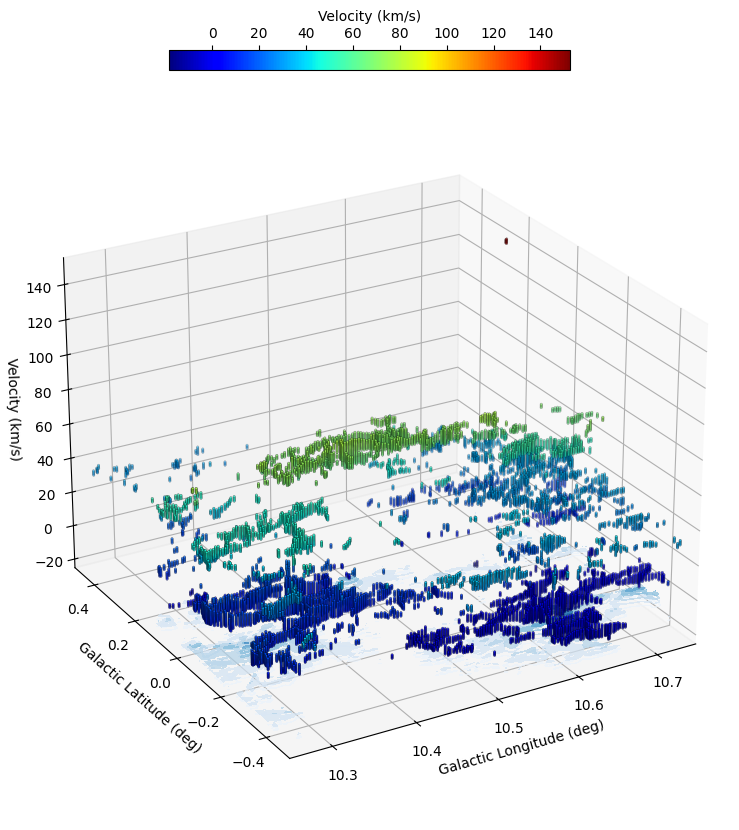

In [81]:
fig = plt.figure(figsize=(10, 10))
#ax1.set_yticks(['96',  '98', '100', '102', '104', '106'])
#ax1.contour(X1, Z1, np.nanmean(cube, axis=1), levels=5, alpha=0.7, color='w')
ax3 = fig.add_subplot(111, projection='3d')
# --- 3D scatter (les points du cube) ---
p = ax3.scatter3D(l1, b1, velocity1, c=velocity1, cmap='jet', s=3, edgecolor='black' ,linewidths=0.3)
ax3.contourf(X, Y, (mean_above_a0 + zmin ) , cmap='Blues', levels=levels[1:], alpha=0.7) # * 0.001
fig.colorbar(p, ax=ax3, label='Velocity (km/s)', shrink=0.7,orientation='horizontal', location='top' , pad=0.04 ,fraction=0.026)

# --- Moment-0 map comme fond (plan z=zmin) ---
#ax1.contourf(X, Y, (data2 * 0.001) + zmin, cmap='Blues', levels=levels, alpha=0.7)

ax3.set_xlabel('Galactic Longitude (deg)')
ax3.set_ylabel('Galactic Latitude (deg)')
ax3.set_zlabel('Velocity (km/s)')
ax3.set_xlim(xmin, xmax)
ax3.set_ylim(ymin, ymax)
ax3.set_zlim(zmin-5, zmax)

ax3.view_init(elev=25, azim=240)  # angle de vue 3D




In [ ]:
## Annie Plot with Plotly

In [616]:
import numpy as np
import plotly.graph_objects as go
import plotly.colors as pc
from plotly.subplots import make_subplots
pio.renderers.default = "browser"
# === Préparation des données ===
iz_min = np.where(v_vals >= z_s.min() - 2)[0][0]
iz_max = np.where(v_vals >= z_s.max() + 2)[0][0]
zmin = v_vals[iz_min]
zmax = v_vals[iz_max]
cube = data_reproject[0].data[iz_min:iz_max, :, :]
cube = np.nan_to_num(cube, nan=0.0)
threshold = np.percentile(cube, 99.6)
nz, ny, nx = cube.shape

z, y, x = np.where(cube > threshold)
x, y = wcs_cube.all_pix2world(x, y, 1)
z = v_vals[z]
values = cube[cube > threshold]

xmin, xmax = min_ra, max_ra
ymin, ymax = min_dec, max_dec

# Moyennes selon les axes
mask = cube > threshold
mean_above_a0 = np.nan_to_num(np.nansum(cube * mask, axis=0) / np.nansum(mask, axis=0), 0.0)
mean_above_a1 = np.nanmean(cube, axis=1)
mean_above_a2 = np.nanmean(cube, axis=2)

# Coordonnées pour les projections
ra = np.linspace(xmin, xmax, nx)
dec = np.linspace(ymin, ymax, ny)
vitesse = np.linspace(zmin, zmax, nz)
X1, Z1 = np.meshgrid(ra, vitesse)
Y2, Z2 = np.meshgrid(dec, vitesse)
X, Y = np.meshgrid(ra, dec)
vmin1 = -mean_above_a1.min() + 0.02
vmax1 = mean_above_a1.max()
vmin2 = -mean_above_a2.min() + 0.02
vmax2 = mean_above_a2.max()

levels1 = np.linspace(np.min(mean_above_a1)+0.02, np.max(mean_above_a1)-1.7, 8)
levels2 = np.linspace(np.min(mean_above_a2)+0.02, np.max(mean_above_a2)-2.9, 8)

#levels1 = np.linspace(np.min(mean_above_a1)+0.5, np.max(mean_above_a1)-1.7, 8)
#levels2 = np.linspace(np.min(mean_above_a2)+0.65, np.max(mean_above_a2)-2.9, 8)

# === Création de la figure Plotly ===
fig = make_subplots(
    rows=2, cols=2,
    specs=[[{"type": "heatmap"}, {"type": "heatmap"}],
           [{"type": "scatter3d", "colspan": 2}, None]],
    subplot_titles=["Longitude–Velocity", "Latitude–Velocity", "3D Scatter + Moment Map"],
    horizontal_spacing=0.08,
    vertical_spacing=0.12
)

# --- 1️⃣ Longitude–Velocity (ax1)
fig.add_trace(
    go.Heatmap(
        x=ra,
        y=vitesse,
        z=mean_above_a1,
        zmin=vmin1,
        zmax=vmax1,
        colorscale="Jet",
        colorbar=dict(title="mK degree", orientation="h",
            x=0.23,  y=1.05,
            len=0.35,
            thickness=10
            ),
        showscale=True
    ),
row=1, col=1
)
fig.add_trace(go.Contour(
    x=ra,
    y=vitesse,
    z=mean_above_a1,
    contours=dict(
        showlines=True,
        coloring="none",
        start=levels1.min(),
        end=levels1.max(),
        size=(levels1[2]-levels1[0])
    ),
    line=dict(color="white", width=1.0),
    showscale=False
), row=1, col=1)
# --- 2️⃣ Latitude–Velocity (ax2)
fig.add_trace(go.Heatmap(
    x=np.linspace(ymin, ymax, mean_above_a2.shape[1]),
    y=np.linspace(zmin, zmax, mean_above_a2.shape[0]),
    z=mean_above_a2,
    colorscale="Jet",
    zmin=vmin2, zmax=vmax2,
    colorbar=dict(
        title="mK degree",
        orientation="h",
        x=0.77, y=1.05,
        len=0.35,
        thickness=10
    ),
), row=1, col=2)


fig.add_trace(go.Contour(
    x=np.linspace(ymin, ymax, mean_above_a2.shape[1]),
    y=np.linspace(zmin, zmax, mean_above_a2.shape[0]),
    z=mean_above_a2,
    contours=dict(
        showlines=True,
        coloring="none",
        start=levels2.min(),
        end=levels2.max(),
        size=(levels2[2]-levels2[0])
    ),
    line=dict(color="white", width=1.2),
    showscale=False
), row=1, col=2)
# --- 3️⃣ Vue 3D (ax3)
fig.add_trace(
    go.Scatter3d(
        x=x_s, y=y_s, z=z_s,
        mode='markers',
        marker=dict(
            size=2,
            color=z_s,
            cmin=np.nanmin(z_s),
            cmax=np.nanmax(z_s),
            #line=dict(
            #    color='black',
            #    width=0.005
            #),
            opacity=0.7,
            colorscale='Jet',
            colorbar=dict(title="Velocity (km/s)", orientation='h', len=0.45,  x=0.5, y=-0.1,  thickness=12),
        ),
        name='Skeleton Pics points'
    ),
    row=2, col=1
)

# --- Moment-0 map en fond (z=zmin)
fig.add_trace(
    go.Surface(
        x=X, y=Y, z=np.zeros_like(X) + zmin,
        surfacecolor=mean_above_a0 + zmin,
        colorscale='Blues',
        opacity=0.7,
        showscale=False
    ),
    row=2, col=1
)

# === Layout et axes ===
fig.update_layout(
    height=900, width=1000,
    template="plotly_white",
    scene=dict(
        xaxis_title='Galactic Longitude (deg)',
        yaxis_title='Galactic Latitude (deg)',
        zaxis_title='Velocity (km/s)',
        aspectmode='manual',
        aspectratio=dict(x=1.1, y=1.1, z=1),
        camera=dict(eye=dict(x=1.3, y=1.5, z=0.9)),
        bgcolor="rgba(255,255,255,1)"
    ),
    title=dict(
        text="3D Cube + Velocity Maps (Improved Plotly Version)",
        y=1.,
        x=0.5,
        xanchor="center",
        yanchor="top"
    ),
    paper_bgcolor="white",
    plot_bgcolor="white"
)

fig.show()
fig.write_html(f"figures/figureannie5_ske{i_skeleton}.html")


invalid value encountered in divide


In [481]:
zmin

np.float64(-10.053083562997301)

In [ ]:
zfactor = 30.
scene_radec = {
    'eye': {'x': zfactor*2.2, 'y': zfactor*0.8, 'z': zfactor*0.2},
    'center': {'x': 0, 'y': 0, 'z': -.1},
}

# RA / Vrad view
zfactor = 50.
scene_ravrad = {
    'eye': {'x': zfactor*-2, 'y': zfactor*-10, 'z': zfactor*2.4},
    'center': {'x': 0, 'y': 0, 'z': -.1},
}

fig.update_layout(
    scene = {
        'xaxis_title': 'vrad [m/s]',
        'yaxis_title': 'RA [deg]',
        'zaxis_title': 'Dec [deg]',
    },

    width=WIDTH,
    height=HEIGHT,
    margin={'r': 10, 'b': 10, 'l': 10, 't': 10},
    scene_camera=scene_ravrad,
)

fig.update_scenes(
    aspectmode='manual',
    aspectratio = {
        'x': cube.shape[0],
        'y': cube.shape[1],
        'z': cube.shape[2],
    }
)


fig.update_layout(
    scene=dict(
        aspectmode='cube',
        xaxis_title='X',
        yaxis_title='Y',
        zaxis_title='Z'
    ),
    width=900,
    height=900,
    title="3D Cube with Skeleton Overlay"
)
fig.show()




In [49]:

header_reproject = data_reproject[0].header
cube_shape = data_reproject[0].data.shape  # (velocity, y, x)
wcs_reproject = WCS(header_reproject).celestial

corners_world = wcs_reproject.calc_footprint()
cube_corners_icrs = SkyCoord(corners_world, unit="deg", frame="icrs")
print(corners_world)
print("cube_corners_icrs ", cube_corners_icrs)
print(cube_corners_icrs)
min_ra, min_dec = corners_world.min(axis=0)
max_ra, max_dec = corners_world.max(axis=0)
data_s2_wcs = WCS(data_spine[0].header)

corners_world_s2 = data_s2_wcs.calc_footprint()
print("corners_world_s2", corners_world_s2)
# s2_corners_icrs = SkyCoord(corners_world_s2, unit="deg", frame="galactic")

spine_corners_gal = SkyCoord(corners_world_s2, unit='deg', frame='galactic')
print("spine_corners_gal",  spine_corners_gal )
# Convertir spine corners en RA/DEC ICRS
spine_corners_icrs = spine_corners_gal.icrs
print("pine_corners_icrs ", spine_corners_icrs)

# Find these corners inside 2D mask data
min_pix_x, min_pix_y = data_s2_wcs.world_to_pixel_values(min_ra, min_dec)
max_pix_x, max_pix_y = data_s2_wcs.world_to_pixel_values(max_ra, max_dec)
min_pix_x, max_pix_x = int(min_pix_x), int(max_pix_x)
min_pix_y, max_pix_y = int(min_pix_y), int(max_pix_y)
print(" min_pix_x, max_pix_x", min_pix_x, max_pix_x)
print("min_pix_y, max_pix_y ", min_pix_y, max_pix_y)

[[10.75145453 -0.50370991]
 [10.75144773  0.49295675]
 [10.2531148   0.49295355]
 [10.25312079 -0.50371311]]
cube_corners_icrs  <SkyCoord (ICRS): (ra, dec) in deg
    [(10.75145453, -0.50370991), (10.75144773,  0.49295675),
     (10.2531148 ,  0.49295355), (10.25312079, -0.50371311)]>
corners_world_s2 [[12.76716354 -1.77827616]
 [12.76712762  1.76755717]
 [ 0.40466351  1.76755724]
 [ 0.40462755 -1.77827609]]
spine_corners_gal <SkyCoord (Galactic): (l, b) in deg
    [(12.76716354, -1.77827616), (12.76712762,  1.76755717),
     ( 0.40466351,  1.76755724), ( 0.40462755, -1.77827609)]>
pine_corners_icrs  <SkyCoord (ICRS): (ra, dec) in deg
    [(275.00141144, -18.71129798), (271.73095088, -17.01291979),
     (264.93966301, -27.66201124), (268.39118623, -29.5028812 )]>
 min_pix_x, max_pix_x 787 630
min_pix_y, max_pix_y  399 710
